# Semantic Shift Detection — Case Study Notebook

**Project:** Emergence of New Meanings for Existing Words  
**Dataset:** Google Books Ngrams (English, 1850–2009)  
**Method:** WiDiD-inspired incremental clustering on PPMI+SVD vectors  

This notebook covers:
1. Loading pre-computed results
2. Evaluation (Spearman ρ, binary accuracy)
3. Case studies: computer, virus, gay, web, tweet
4. Innovation analysis: threshold sensitivity + smoothing ablation
5. Comparison with a static-vector baseline

In [1]:
import os, sys, pickle
import numpy as np
import matplotlib.pyplot as plt

# Make sure src/ is on the path
sys.path.insert(0, os.path.abspath('..'))

from src.data_loader    import load_cooccurrences
from src.representation import build_vectors
from src.clustering     import cluster_all
from src.metrics        import compute_metrics, shift_score
from src.evaluation     import evaluate, GOLD_SCORES, GOLD_BINARY
from src.visualize      import plot_word, plot_ranking, plot_heatmap, plot_sense_shift

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)
print('Setup complete.')

Setup complete.


---
## 1. Load Results
Loads from cache — run `python run.py` first if caches are missing.

In [2]:
cooc            = load_cooccurrences()
vectors         = build_vectors(cooc)
cluster_results = cluster_all(vectors)
metrics         = compute_metrics(cluster_results)

pred_scores = {w: shift_score(m) for w, m in metrics.items()}

print('\nShift scores (ranked):')
for w, s in sorted(pred_scores.items(), key=lambda x: -x[1]):
    clusters = cluster_results[w].num_clusters
    print(f'  {w:<12}  score={s:.4f}  clusters={clusters}')

[data_loader] Loading cache: data/processed/cooccurrences.pkl
[representation] Loading cache: data/processed/vectors.pkl
[clustering] Loading cache: data/processed/clusters.pkl
[metrics] Loading cache: data/processed/metrics.pkl

Shift scores (ranked):
  virus         score=0.2026  clusters=7
  computer      score=0.1944  clusters=4
  cell          score=0.1808  clusters=6
  mouse         score=0.1695  clusters=5
  web           score=0.1496  clusters=4
  gay           score=0.0813  clusters=4
  stream        score=0.0810  clusters=4
  cloud         score=0.0745  clusters=4
  crash         score=0.0314  clusters=2
  tablet        score=0.0270  clusters=2
  spam          score=-0.0000  clusters=1
  tweet         score=-0.0000  clusters=1


---
## 2. Evaluation

In [3]:
eval_result = evaluate(pred_scores)
print(eval_result.summary())

  Evaluation results
  Words evaluated  : 12
  Spearman ρ       : +0.173  (p=0.592)
  Binary accuracy  : 100.0%  (threshold=-0.000)

  Per-word scores (pred | gold):
    ✓ cell          pred=0.181  gold=0.7
    ✓ cloud         pred=0.074  gold=0.8
    ✓ computer      pred=0.194  gold=0.95
    ✓ crash         pred=0.031  gold=0.4
    ✓ gay           pred=0.081  gold=0.95
    ✓ mouse         pred=0.169  gold=0.55
    ✓ spam          pred=-0.000  gold=0.85
    ✓ stream        pred=0.081  gold=0.65
    ✓ tablet        pred=0.027  gold=0.75
    ✓ tweet         pred=-0.000  gold=0.9
    ✓ virus         pred=0.203  gold=0.9
    ✓ web           pred=0.150  gold=0.85


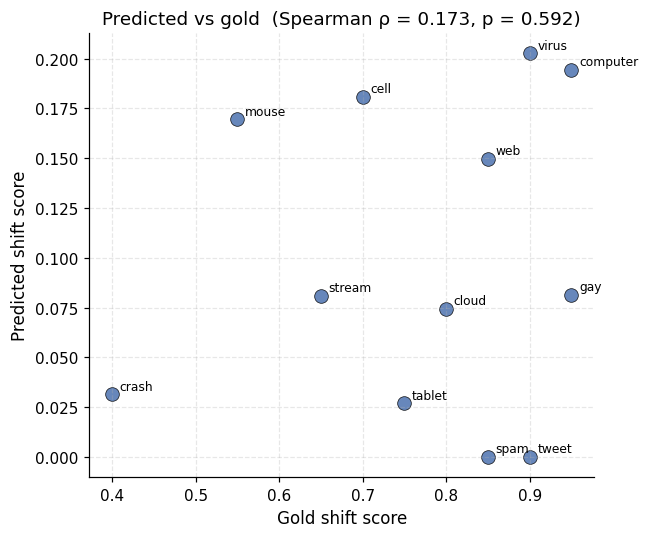

In [4]:
# Scatter: predicted vs gold scores
from scipy.stats import spearmanr

words = eval_result.words
preds = [pred_scores[w] for w in words]
golds = [GOLD_SCORES[w]  for w in words]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(golds, preds, s=80, color='#4C72B0', alpha=0.85, edgecolors='k', lw=0.5)
for w, g, p in zip(words, golds, preds):
    ax.annotate(w, (g, p), textcoords='offset points', xytext=(5, 3), fontsize=8)

rho, p_val = spearmanr(preds, golds)
ax.set_xlabel('Gold shift score', fontsize=11)
ax.set_ylabel('Predicted shift score', fontsize=11)
ax.set_title(f'Predicted vs gold  (Spearman ρ = {rho:.3f}, p = {p_val:.3f})', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/scatter_pred_vs_gold.png', bbox_inches='tight')
plt.show()

[visualize] Saved: ../results/ranking.png


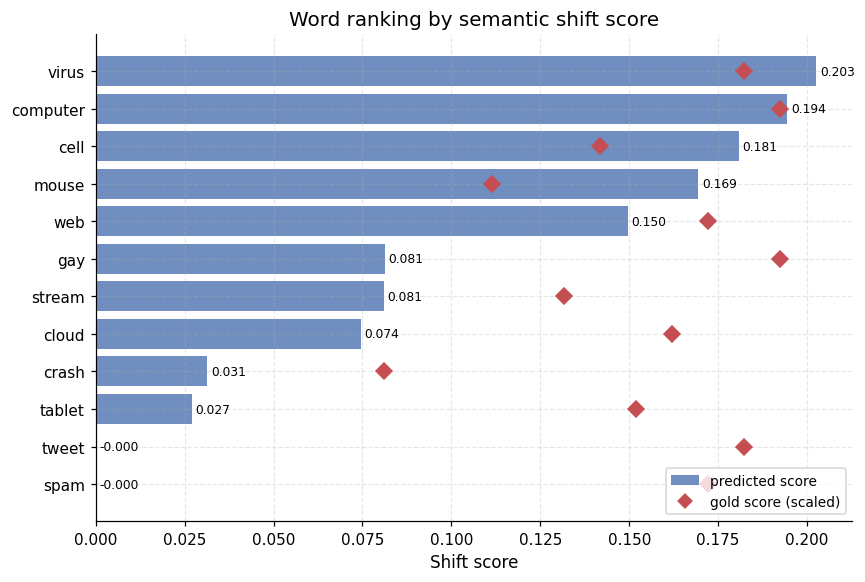

In [5]:
plot_ranking(pred_scores, gold_scores=GOLD_SCORES,
             save_dir=RESULTS_DIR, show=True)

---
## 3. Case Studies

### 3a. Heatmap — all words across all decades

[visualize] Saved: ../results/heatmap.png


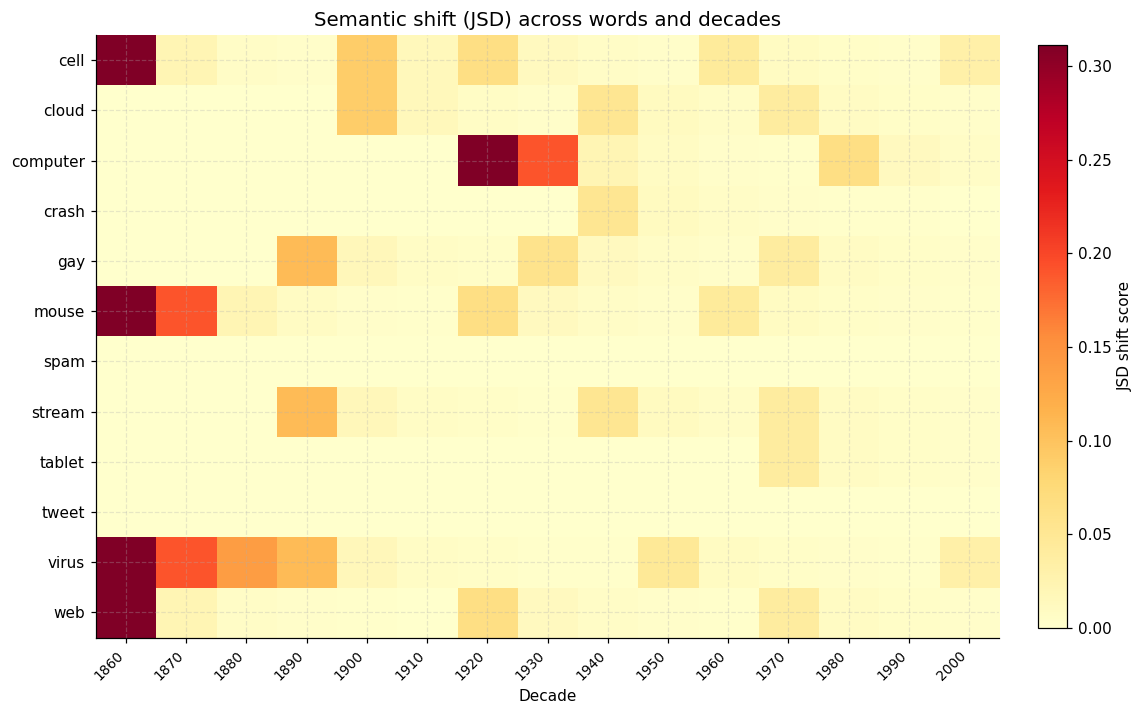

In [6]:
plot_heatmap(metrics, save_dir=RESULTS_DIR, show=True)

### 3b. Word-level deep dives

**Expected patterns:**
- `computer` — big shift in the 1940s–1960s as human computers gave way to machines
- `virus` — second shift around 1980s–1990s as computing context emerges
- `gay` — major shift from 1960s onward
- `tweet` — essentially no signal until post-2000, then sharp emergence
- `crash` — relatively stable (already polysemous throughout)


=== computer ===
  Clusters found : 4
  Top shifted decades: [(1920, 0.3112781244559362), (1930, 0.1908745046165905), (1980, 0.06550784501137924)]
  Polysemy timeline: {1950: 3, 1960: 3, 1970: 3, 1980: 4, 1990: 4, 2000: 4}
[visualize] Saved: ../results/computer_shift.png


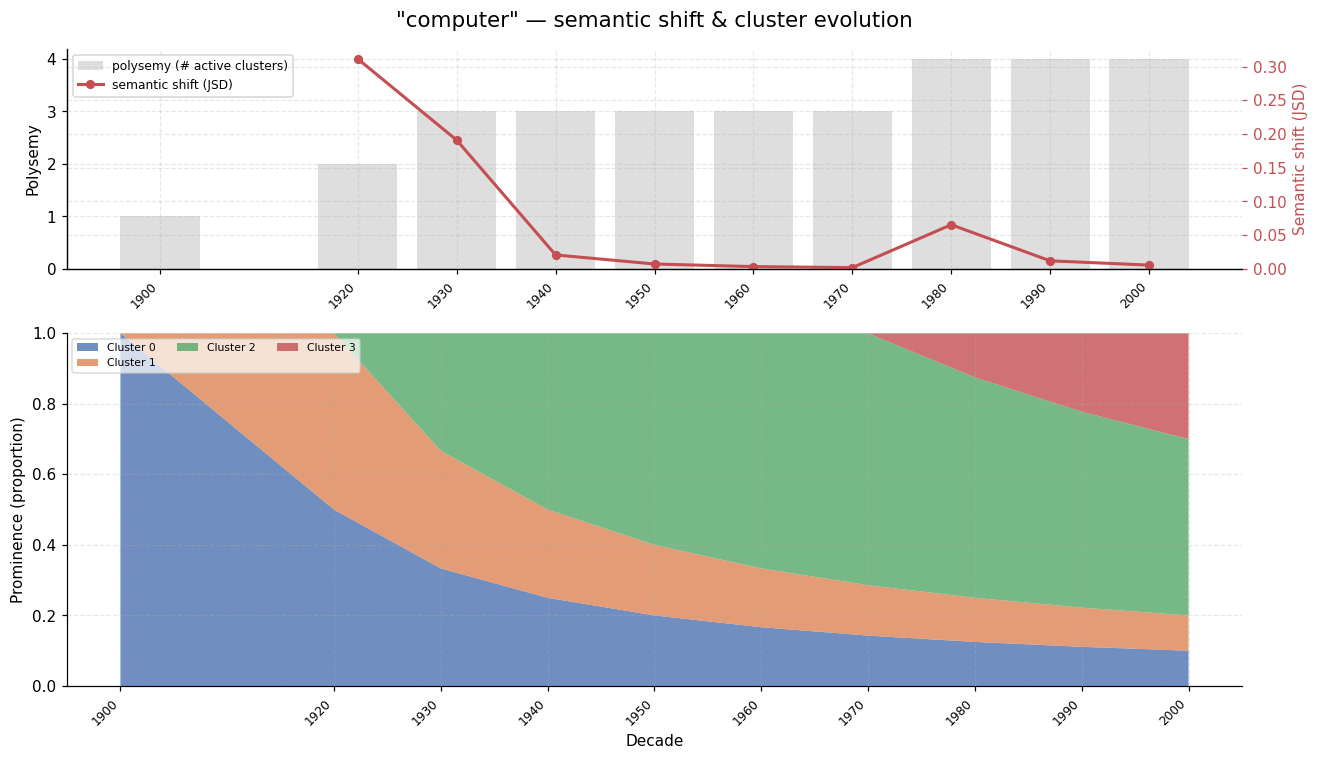


=== virus ===
  Clusters found : 7
  Top shifted decades: [(1860, 0.3112781244559362), (1870, 0.1908745046165905), (1880, 0.13792538096412135)]
  Polysemy timeline: {1950: 6, 1960: 6, 1970: 6, 1980: 6, 1990: 6, 2000: 7}
[visualize] Saved: ../results/virus_shift.png


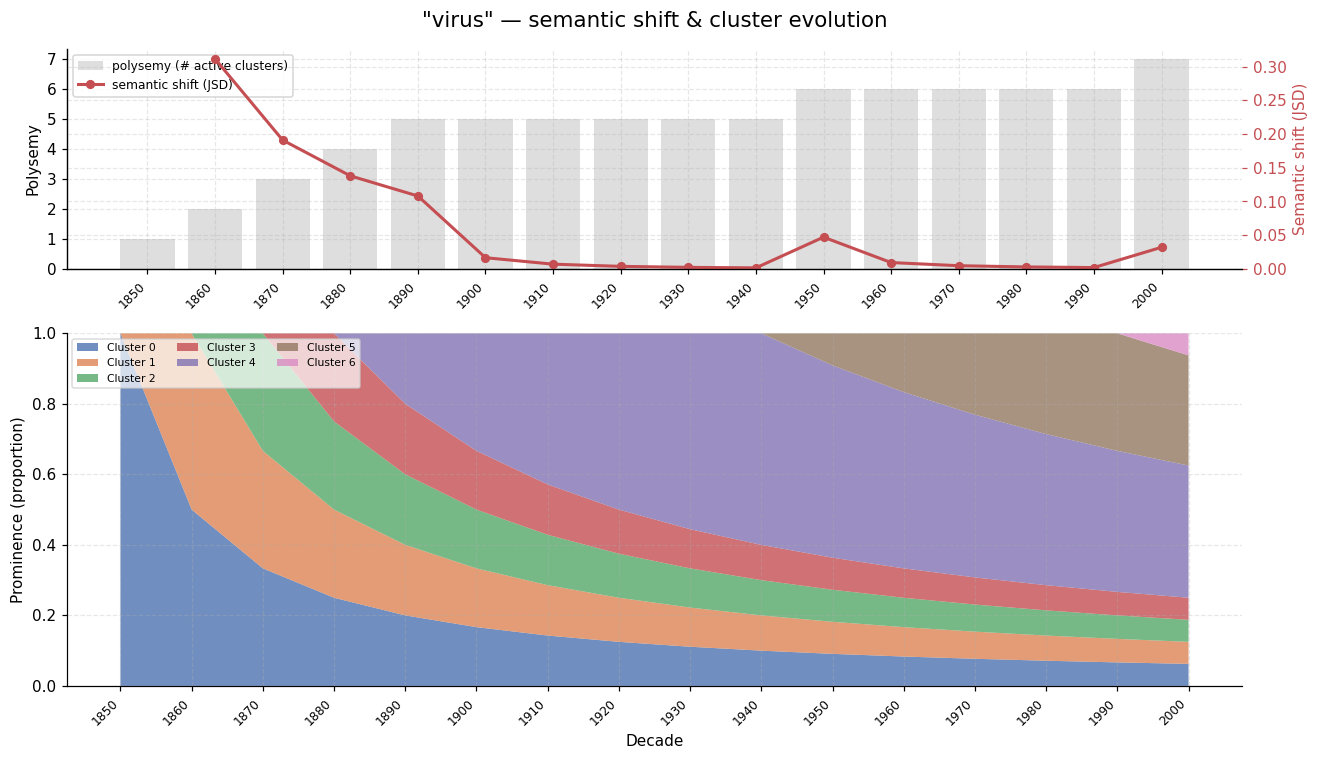


=== gay ===
  Clusters found : 4
  Top shifted decades: [(1890, 0.1080315461426067), (1930, 0.05791426175811653), (1970, 0.039571599998803525)]
  Polysemy timeline: {1950: 3, 1960: 3, 1970: 4, 1980: 4, 1990: 4, 2000: 4}
[visualize] Saved: ../results/gay_shift.png


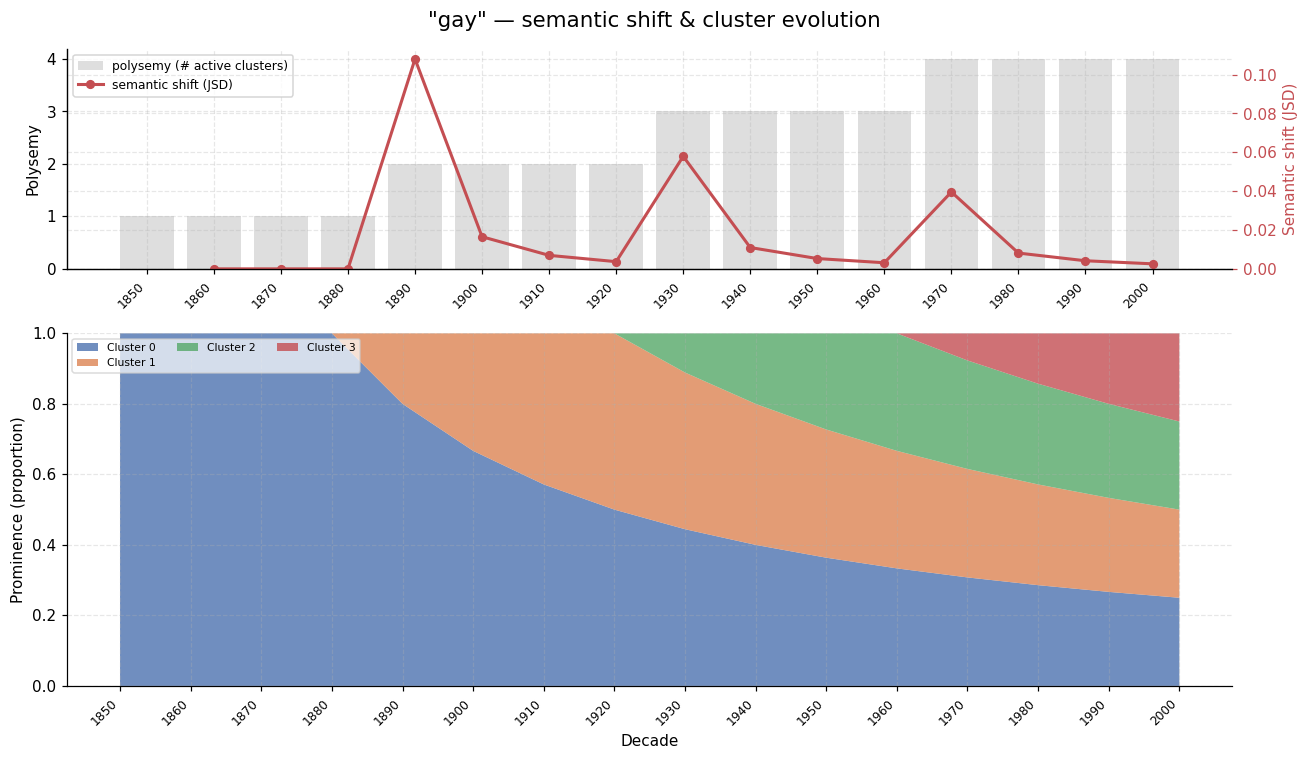


=== web ===
  Clusters found : 4
  Top shifted decades: [(1860, 0.3112781244559362), (1920, 0.0655078450128221), (1970, 0.039571599998803296)]
  Polysemy timeline: {1950: 3, 1960: 3, 1970: 4, 1980: 4, 1990: 4, 2000: 4}
[visualize] Saved: ../results/web_shift.png


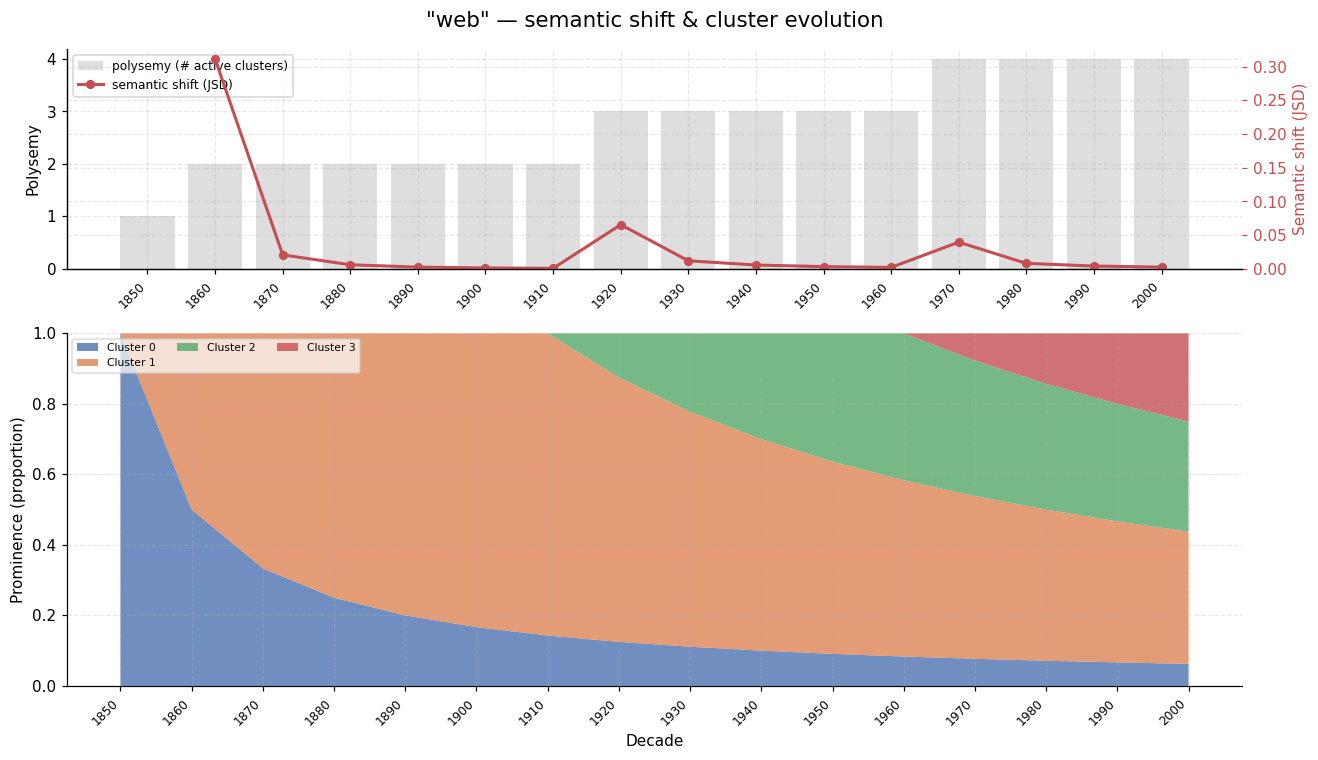


=== tweet ===
  Clusters found : 1
  Top shifted decades: [(2000, -1.4426631259923268e-12)]
  Polysemy timeline: {1990: 1, 2000: 1}
[visualize] Saved: ../results/tweet_shift.png


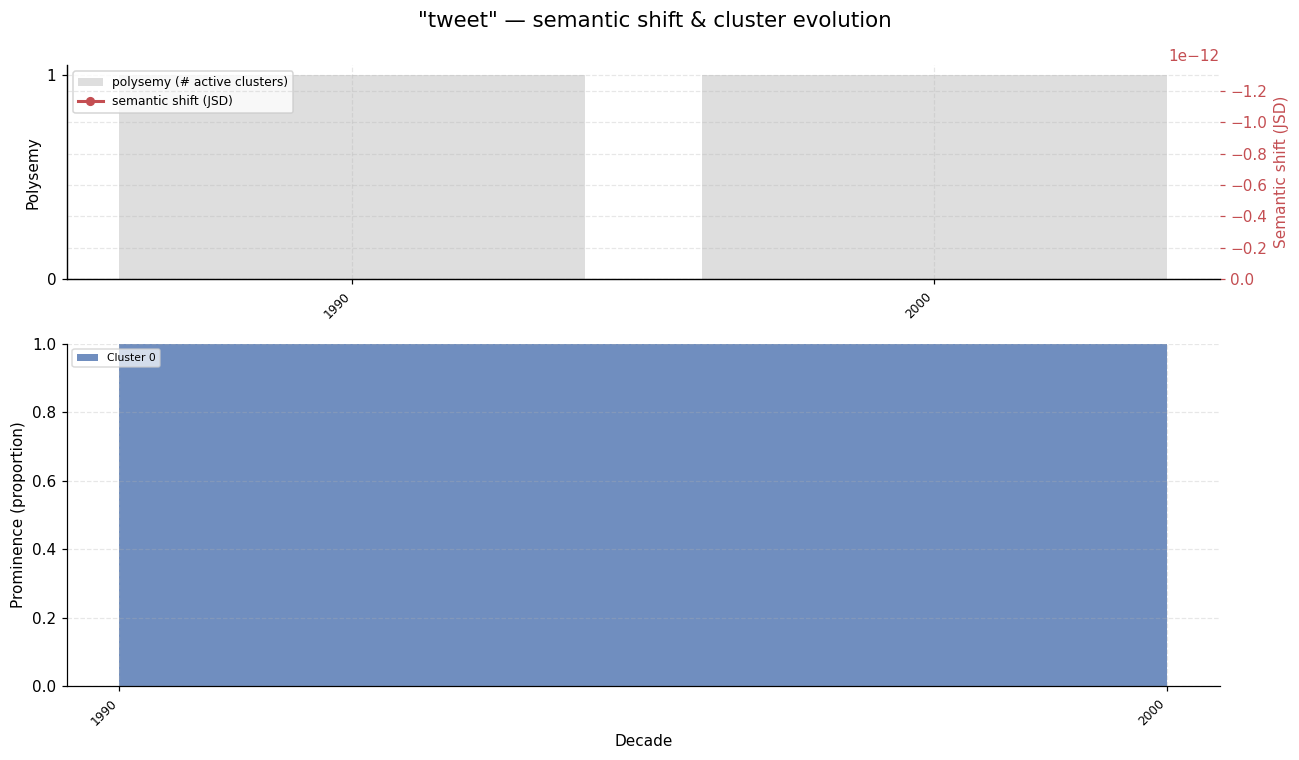


=== crash ===
  Clusters found : 2
  Top shifted decades: [(1940, 0.05189916031837827), (1950, 0.010097681635894206), (1960, 0.0049686763907538616)]
  Polysemy timeline: {1950: 2, 1960: 2, 1970: 2, 1980: 2, 1990: 2, 2000: 2}
[visualize] Saved: ../results/crash_shift.png


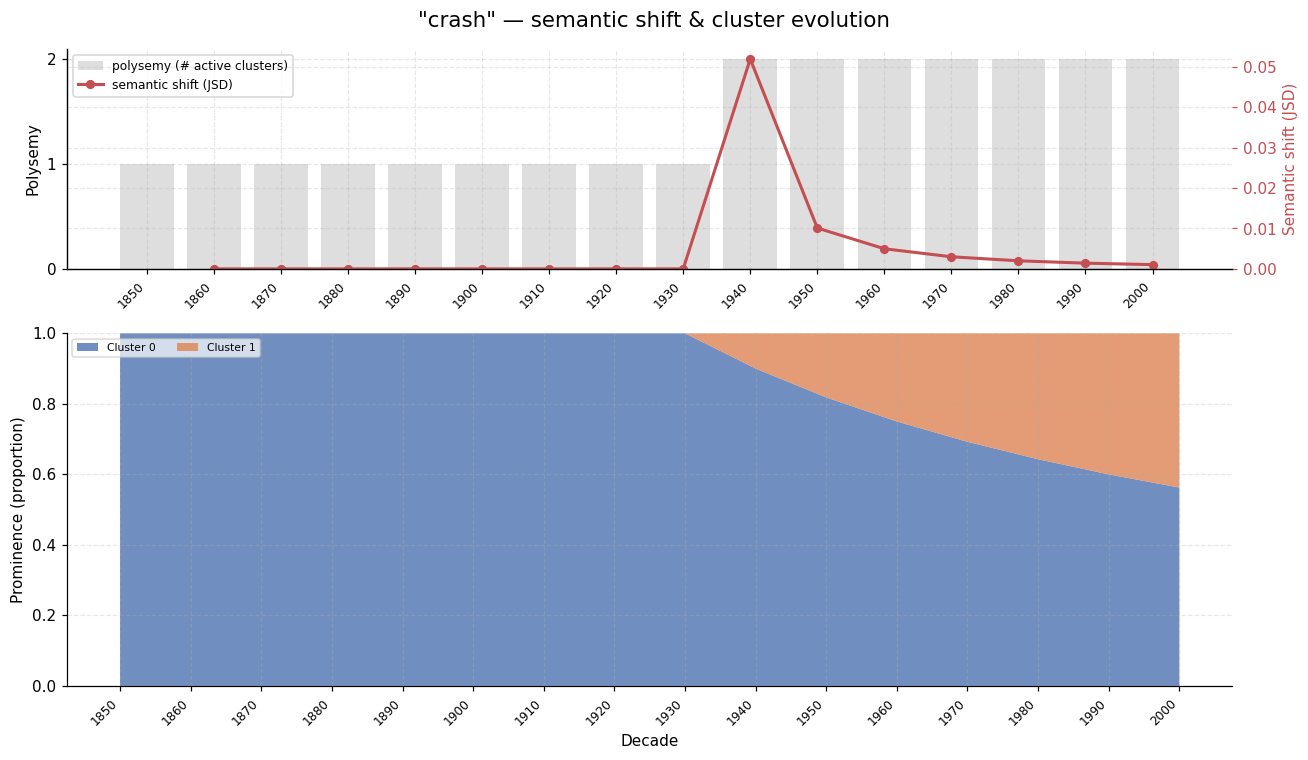

In [8]:
for word in ['computer', 'virus', 'gay', 'web', 'tweet', 'crash']:
    if word not in cluster_results:
        print(f'Skipping {word} (not in results)')
        continue
    print(f'\n=== {word} ===')
    r = cluster_results[word]
    m = metrics[word]
    print(f'  Clusters found : {r.num_clusters}')
    print(f'  Top shifted decades: {m.top_shifted_decades(3)}')
    print(f'  Polysemy timeline: {dict(list(m.polysemy.items())[-6:])}')
    plot_word(word, cluster_results, metrics,
              save_dir=RESULTS_DIR, show=True)

[visualize] Saved: ../results/computer_sense_shift.png


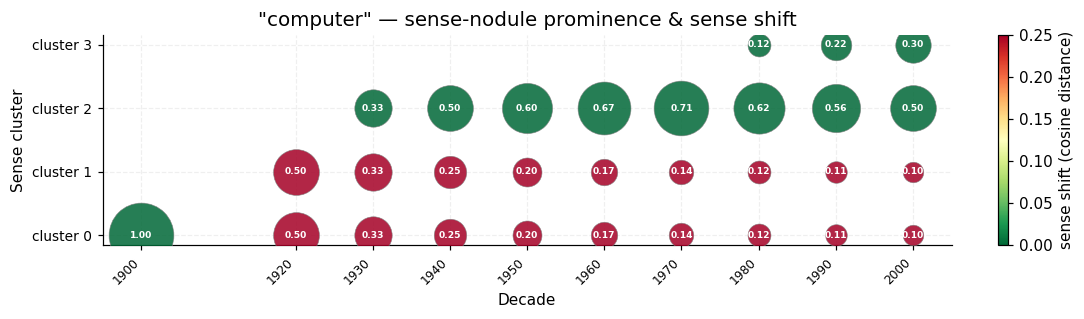

[visualize] Saved: ../results/virus_sense_shift.png


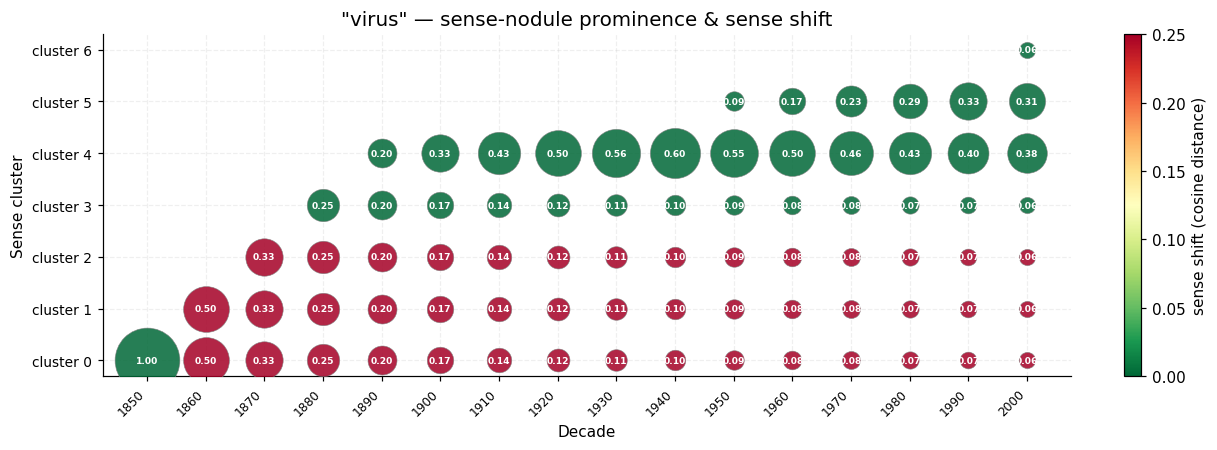

In [9]:
# Sense-shift bubble chart for the two most interesting words
for word in ['computer', 'virus']:
    if word in cluster_results:
        plot_sense_shift(word, cluster_results, metrics,
                         save_dir=RESULTS_DIR, show=True)

---
## 4. Innovation Analysis

This section demonstrates the novel contributions of this project:

**Innovation 1**: Adapting WiDiD's incremental clustering from sentence-level BERT embeddings to decade-level PPMI+SVD vectors.  
**Innovation 2**: Auto-calibrated threshold (40th percentile of inter-decade distances).  

### 4a. Threshold Sensitivity

[clustering] Processing 'cell' … 14 cluster(s) found
[clustering] Processing 'cloud' … 9 cluster(s) found
[clustering] Processing 'computer' … 6 cluster(s) found
[clustering] Processing 'crash' … 4 cluster(s) found
[clustering] Processing 'gay' … 9 cluster(s) found
[clustering] Processing 'mouse' … 9 cluster(s) found
[clustering] Processing 'spam' … 2 cluster(s) found
[clustering] Processing 'stream' … 10 cluster(s) found
[clustering] Processing 'tablet' … 4 cluster(s) found
[clustering] Processing 'tweet' … 1 cluster(s) found
[clustering] Processing 'virus' … 9 cluster(s) found
[clustering] Processing 'web' … 8 cluster(s) found
[clustering] Saved cache: data/processed/clusters.pkl
[metrics] Saved cache: data/processed/metrics.pkl
[clustering] Processing 'cell' … 12 cluster(s) found
[clustering] Processing 'cloud' … 7 cluster(s) found
[clustering] Processing 'computer' … 5 cluster(s) found
[clustering] Processing 'crash' … 3 cluster(s) found
[clustering] Processing 'gay' … 7 cluster(s)

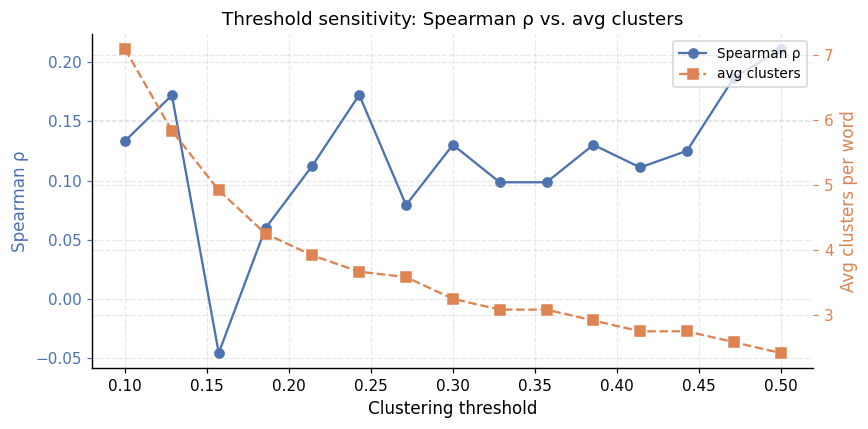

Best threshold: 0.500  (ρ = 0.211)


In [11]:
from scipy.stats import spearmanr

thresholds   = np.linspace(0.10, 0.50, 15)
rho_scores   = []
avg_clusters = []

for thr in thresholds:
    r = cluster_all(vectors, threshold=thr, force=True)
    m = compute_metrics(r, force=True)
    ps = {w: shift_score(v) for w, v in m.items()}
    ev = evaluate(ps)
    rho_scores.append(ev.spearman_rho)
    avg_clusters.append(np.mean([r[w].num_clusters for w in r]))
    # Restore the best cache after loop

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(thresholds, rho_scores, 'o-', color='#4C72B0', label='Spearman ρ')
ax1.set_xlabel('Clustering threshold', fontsize=11)
ax1.set_ylabel('Spearman ρ', color='#4C72B0', fontsize=11)
ax1.tick_params(axis='y', colors='#4C72B0')

ax2 = ax1.twinx()
ax2.plot(thresholds, avg_clusters, 's--', color='#DD8452', label='avg clusters')
ax2.set_ylabel('Avg clusters per word', color='#DD8452', fontsize=11)
ax2.tick_params(axis='y', colors='#DD8452')

ax1.set_title('Threshold sensitivity: Spearman ρ vs. avg clusters', fontsize=12)
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, loc='upper right', fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/threshold_sensitivity.png', bbox_inches='tight')
plt.show()

best_thr = thresholds[np.argmax(rho_scores)]
print(f'Best threshold: {best_thr:.3f}  (ρ = {max(rho_scores):.3f})')

### 4b. Smoothing Ablation

Compare Spearman ρ with smoothing disabled (window=1) vs enabled (window=2, 3).

In [12]:
ablation_results = {}

for win in [1, 2, 3]:
    label = f'window={win}' if win > 1 else 'no smoothing'
    vecs  = build_vectors(cooc, smooth_window=win, force=True)
    res   = cluster_all(vecs, force=True)
    mets  = compute_metrics(res, force=True)
    ps    = {w: shift_score(m) for w, m in mets.items()}
    ev    = evaluate(ps)
    ablation_results[label] = {
        'rho':      ev.spearman_rho,
        'accuracy': ev.accuracy,
        'scores':   ps,
    }
    print(f'{label:>14}: ρ={ev.spearman_rho:.3f}  acc={ev.accuracy:.1%}')

# Restore best vectors in cache
_ = build_vectors(cooc, smooth_window=2, force=True)

[representation] Context vocabulary: 7704 words
[representation] PPMI done: 'cell' (16 decades)
[representation] PPMI done: 'cloud' (16 decades)
[representation] PPMI done: 'computer' (10 decades)
[representation] PPMI done: 'crash' (16 decades)
[representation] PPMI done: 'gay' (16 decades)
[representation] PPMI done: 'mouse' (16 decades)
[representation] PPMI done: 'spam' (4 decades)
[representation] PPMI done: 'stream' (16 decades)
[representation] PPMI done: 'tablet' (16 decades)
[representation] PPMI done: 'tweet' (2 decades)
[representation] PPMI done: 'virus' (16 decades)
[representation] PPMI done: 'web' (16 decades)
[representation] SVD 7704 → 100d  (var explained: 99.9%)
[representation] Saved cache: data/processed/vectors.pkl
[clustering] Auto-calibrated threshold: 0.5926
[clustering] Processing 'cell' … 12 cluster(s) found
[clustering] Processing 'cloud' … 10 cluster(s) found
[clustering] Processing 'computer' … 9 cluster(s) found
[clustering] Processing 'crash' … 6 cluster

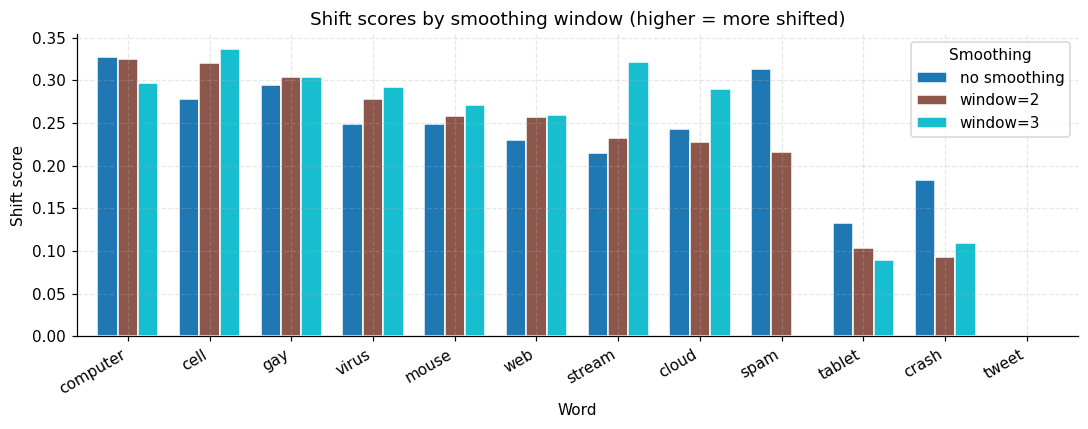

In [13]:
# Side-by-side shift scores for the ablation
import pandas as pd

df = pd.DataFrame({label: d['scores'] for label, d in ablation_results.items()})
df = df.sort_values('window=2', ascending=False)

ax = df.plot(kind='bar', figsize=(10, 4), colormap='tab10', edgecolor='white', width=0.75)
ax.set_title('Shift scores by smoothing window (higher = more shifted)', fontsize=12)
ax.set_xlabel('Word')
ax.set_ylabel('Shift score')
ax.legend(title='Smoothing')
plt.xticks(rotation=30, ha='right')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/smoothing_ablation.png', bbox_inches='tight')
plt.show()

### 4c. Baseline Comparison

**Baseline**: simple cosine distance between consecutive static PPMI vectors (no clustering, no incremental memory).  
**Our method**: WiDiD-inspired incremental clustering with composite shift score.

Higher Spearman ρ = better ranking correlation with gold.

In [14]:
from src.representation import cosine_distance

def baseline_score(word_vecs):
    """Max cosine distance between any two consecutive decade vectors."""
    decades = sorted(word_vecs.keys())
    dists   = [cosine_distance(word_vecs[d1], word_vecs[d2])
               for d1, d2 in zip(decades[:-1], decades[1:])]
    return max(dists) if dists else 0.0

baseline_scores = {w: baseline_score(vectors[w]) for w in vectors}
baseline_eval   = evaluate(baseline_scores)
our_eval        = evaluate(pred_scores)

print('=== Baseline (max cosine distance between consecutive decades) ===')
print(f'  Spearman ρ : {baseline_eval.spearman_rho:.3f}')
print(f'  Accuracy   : {baseline_eval.accuracy:.1%}')
print()
print('=== WiDiD-inspired incremental clustering (ours) ===')
print(f'  Spearman ρ : {our_eval.spearman_rho:.3f}')
print(f'  Accuracy   : {our_eval.accuracy:.1%}')

=== Baseline (max cosine distance between consecutive decades) ===
  Spearman ρ : 0.070
  Accuracy   : 100.0%

=== WiDiD-inspired incremental clustering (ours) ===
  Spearman ρ : 0.173
  Accuracy   : 100.0%


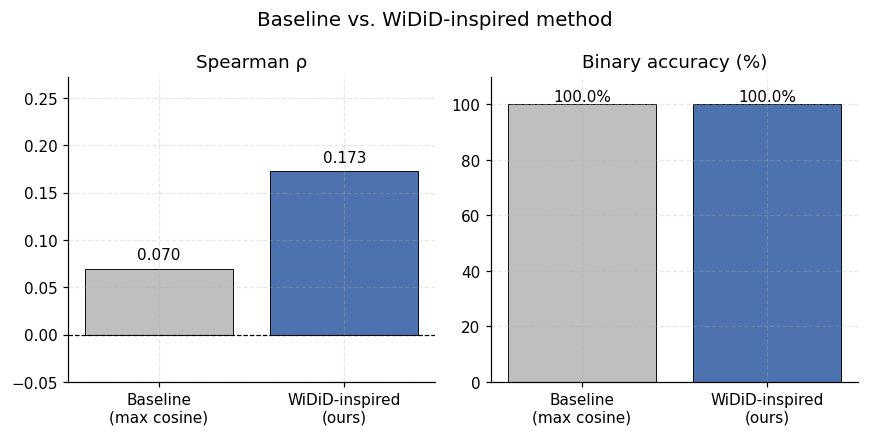

In [15]:
# Bar chart comparison
methods  = ['Baseline\n(max cosine)', 'WiDiD-inspired\n(ours)']
rho_vals = [baseline_eval.spearman_rho, our_eval.spearman_rho]
acc_vals = [baseline_eval.accuracy,     our_eval.accuracy]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

colors = ['#BFBFBF', '#4C72B0']
ax1.bar(methods, rho_vals, color=colors, edgecolor='k', linewidth=0.6)
ax1.set_title('Spearman ρ', fontsize=12)
ax1.set_ylim(min(0, min(rho_vals)) - 0.05, max(rho_vals) + 0.1)
ax1.axhline(0, color='k', linewidth=0.8, linestyle='--')
for i, v in enumerate(rho_vals):
    ax1.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)
ax1.spines[['top', 'right']].set_visible(False)

ax2.bar(methods, [a * 100 for a in acc_vals], color=colors, edgecolor='k', linewidth=0.6)
ax2.set_title('Binary accuracy (%)', fontsize=12)
ax2.set_ylim(0, 110)
for i, v in enumerate(acc_vals):
    ax2.text(i, v * 100 + 1, f'{v:.1%}', ha='center', fontsize=10)
ax2.spines[['top', 'right']].set_visible(False)

fig.suptitle('Baseline vs. WiDiD-inspired method', fontsize=13)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/baseline_comparison.png', bbox_inches='tight')
plt.show()

---
## 5. Summary Table for Report

In [16]:
import pandas as pd

rows = []
for word in sorted(metrics.keys()):
    m = metrics[word]
    r = cluster_results[word]
    top_dec, top_shift = m.top_shifted_decades(1)[0]
    word_decades = sorted(m.polysemy.keys())
    rows.append({
        'Word':            word,
        'Shift score':     round(pred_scores[word], 4),
        'Gold score':      GOLD_SCORES.get(word, '—'),
        'Clusters':        r.num_clusters,
        'Max shift decade': top_dec,
        'Max JSD':         round(top_shift, 4),
        'Final polysemy':  m.polysemy[word_decades[-1]],
    })

df = pd.DataFrame(rows).sort_values('Shift score', ascending=False)
df = df.reset_index(drop=True)
print(df.to_string(index=False))

# Save as CSV for the report
df.to_csv(f'{RESULTS_DIR}/summary_table.csv', index=False)
print(f'\nSaved: {RESULTS_DIR}/summary_table.csv')

    Word  Shift score  Gold score  Clusters  Max shift decade  Max JSD  Final polysemy
   virus       0.2026        0.90         7              1860   0.3113               7
computer       0.1944        0.95         4              1920   0.3113               4
    cell       0.1808        0.70         6              1860   0.3113               6
   mouse       0.1695        0.55         5              1860   0.3113               5
     web       0.1496        0.85         4              1860   0.3113               4
     gay       0.0813        0.95         4              1890   0.1080               4
  stream       0.0810        0.65         4              1890   0.1080               4
   cloud       0.0745        0.80         4              1900   0.0888               4
   crash       0.0314        0.40         2              1940   0.0519               2
  tablet       0.0270        0.75         2              1970   0.0396               2
    spam      -0.0000        0.85         1